
# TSLA Liquidity Zone Analysis

This notebook performs a full **liquidity zone and sweep analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily | Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly | Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

---

## Notebook Structure

| Part | Description |
|---|---|
| **Part 1 — Setup & Data Loading** | Imports, parameters, download/read data, save CSVs, sanity check, load MIDAS order-level data |
| **Part 2 — Core Analytical Functions & Volume Feature Engineering** | Define all helper functions (ATR, SMA, `add_volume_features`, pivot detection, zone builder, sweep detector, tagger, chart, MIDAS enrichers); apply volume features to both timeframes |
| **Part 3 — Daily (HTF) Analysis** | Build and visualise liquidity zones on the daily timeframe; compare zone tables with and without order-level data |
| **Part 4 — Hourly (LTF) Analysis** | Build and visualise liquidity zones on the hourly timeframe; compare zone tables with and without order-level data |
| **Part 5 — Liquidity Sweep Detection** | Detect buy/sell-side sweeps, attach volume features, AVWAP distances, and MIDAS day-of-sweep metrics; compare sweep tables with and without order-level data |
| **Part 6 — Export Results** | Write all outputs to Excel — separate MIDAS comparison sheets included when `USE_MIDAS = True` |



## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to both zone and sweep tables for side-by-side comparison.


In [242]:

# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW     = 20    # rolling window for average volume; smooths single-bar noise to give a reliable activity baseline
VOL_SPIKE_THRESHOLD = 1.5   # vol_ratio >= threshold marks a spike; bars above this likely reflect institutional participation
USE_VOL_FILTER      = True  # when True, only sweeps with elevated volume are flagged, filtering low-conviction breakouts
VOL_PROFILE_BIN_DAILY  = 1.0   # $1 USD bin width for daily POC — coarser bin fits the multi-year price range
VOL_PROFILE_BIN_HOURLY = 0.5   # $0.50 USD bin width for hourly POC — finer bin for intraday price levels

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True  # when True, enrich zones and sweeps with MIDAS institutional microstructure features;
                  # enables side-by-side comparison of analysis with and without order-level data

# ---------------------------------------------------------------------------
# Intraday sweep detection config (LTF focus — three-layer zone filtering)
# ---------------------------------------------------------------------------
# Layer 1: ATR/pivot structure          
# Layer 2: volume + absorption filter   
# Layer 3: MIDAS institutional enrichment filter

MIN_ABSORPTION_SCORE = 0.5   # Layer 2: minimum absorption_score for LTF zone pivots;
                              # a high score means heavy volume with a small candle body —
                              # the bar-level footprint of institutional orders absorbing at a level;
                              # set to 0.0 to disable (HTF context zones use 0.0 by default)

MIDAS_CONFIRM_FIELD  = "hidden_rate_avg"  # Layer 3: MIDAS zone column used for institutional enrichment filtering;
                                          # options: "hidden_rate_avg"      (dark-pool execution fraction)
                                          #          "cancel_to_trade_avg"  (algo probing / spoofing intensity)
                                          #          "fill_rate_avg"        (inverse: low fill = iceberg/spoof)

MIDAS_CONFIRM_PCT    = 50    # Layer 3: percentile threshold for the MIDAS institutional filter (0–100):
                              #   50 = keep zones above median institutional activity (moderate filter)
                              #   75 = keep only top quartile (strict — fewer, higher-conviction zones)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")
print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"POC bins   : daily=${VOL_PROFILE_BIN_DAILY}  |  hourly=${VOL_PROFILE_BIN_HOURLY}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"LTF filter : min_absorption={MIN_ABSORPTION_SCORE}  |  MIDAS_CONFIRM_FIELD={MIDAS_CONFIRM_FIELD}  |  MIDAS_CONFIRM_PCT={MIDAS_CONFIRM_PCT}th pct")


Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones/data/raw
Vol window : 20  |  Spike threshold : 1.5  |  Vol filter : True
POC bins   : daily=$1.0  |  hourly=$0.5
MIDAS data : enabled
LTF filter : min_absorption=0.5  |  MIDAS_CONFIRM_FIELD=hidden_rate_avg  |  MIDAS_CONFIRM_PCT=50th pct


In [243]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [244]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, format='mixed', dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones/data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv ...

Hourly rows : 6577
Date range  : 2021-01-04 09:30:00 -> 2024-09-30 15:30:00


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254
2021-01-04 12:30:00,241.25,244.00,239.97,243.73,1.03%,13451874
2021-01-04 13:30:00,243.70,245.50,242.09,242.49,-0.50%,11721450


In [245]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data/raw/TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv


In [246]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
display(reload_daily.head(3))
print("Hourly head:")
display(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6577, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:


,Close,High,Low,Open,Volume
Datetime,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000


Hourly head:


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254


In [247]:

# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics 
# Highest signal for liquidity zone and sweep quality:
#     Cancel_to_Trade      : cancel-to-trade ratio — spikes signal algo probing / spoofing near a price level
#     Hidden_Rate          : dark-pool execution rate (trade count); indicates stealth institutional positioning
#     Hidden_Volume        : dark-pool volume fraction; volume-weighted complement to Hidden_Rate
#     Trade_to_Order_Volume: order fill rate proxy — persistently low values near zones suggest iceberg / spoof orders
#   Supplementary retail-vs-institutional split:
#     Oddlot_Rate          : odd-lot trade rate — high = retail fragmentation (institutions likely on the other side)
#     Oddlot_Volume        : odd-lot volume fraction

MIDAS_PATH  = Path("data/MIDAS data (TSLA).xlsx")
MIDAS_SHEET = "geoo0rz0bbjsayud"
MIDAS_COLS  = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

if USE_MIDAS:
    midas_df = pd.read_excel(MIDAS_PATH, sheet_name=MIDAS_SHEET, parse_dates=["date"])
    midas_df["date"] = pd.to_datetime(midas_df["date"])
    midas_df = midas_df.set_index("date")[MIDAS_COLS].sort_index()
    midas_df.index = midas_df.index.normalize()   # strip any time-of-day component

    print(f"MIDAS rows   : {len(midas_df)}")
    print(f"Date range   : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
    print(f"Columns      : {midas_df.columns.tolist()}")
    display(midas_df.describe().round(3))
else:
    midas_df = None
    print("USE_MIDAS = False — MIDAS data not loaded.")


MIDAS rows   : 941
Date range   : 2021-01-04 -> 2024-09-30
Columns      : ['Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']


,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
count,941.000,941.000,941.000,941.000,941.000,941.000
mean,18.853,30.190,25.196,3.608,82.085,39.133
std,6.782,8.664,6.648,1.441,8.205,12.850
min,5.700,12.183,10.479,1.115,63.536,19.275
25%,13.630,21.986,19.441,2.498,74.979,27.657
50%,18.270,31.953,25.270,3.318,79.392,32.750
75%,22.839,38.154,30.926,4.519,90.533,51.566
max,46.722,45.673,44.220,10.498,94.521,63.703



## Part 2 — Core Analytical Functions & Volume Feature Engineering

The cells below define all helper functions used in the analysis, including volume feature engineering, MIDAS order-level enrichment, and the three-layer zone filter.

### Helper Functions

| Function | Purpose |
|---|---|
| `atr()` / `sma()` | Average True Range and Simple Moving Average |
| `add_volume_features()` | Append `vol_roll_20`, `vol_ratio`, `vol_spike`, and `absorption_score` to any OHLCV frame |
| `detect_pivots()` | Identify structural pivot highs and lows using a symmetric window |
| `Zone` (dataclass) | Container storing a zone's price bounds, metadata, and volume aggregates |
| **`identify_liquidity_zones()`** | **Main entry point — all three layers in one function.** Layer 1: pivot detection. Layer 2: volume + absorption filter. POC enrichment. Layer 3: MIDAS enrichment + filter. Returns both baseline and MIDAS-enriched zone sets. |
| `compute_volume_poc()` | Bin prices into fixed-width USD bands and find the highest-volume bin (Point of Control) |
| `compute_anchored_vwaps()` | VWAP anchored from the `first_time` of the top-N zones by strength |
| `add_sweep_avwap_dist()` | Attach `dist_to_nearest_avwap` to each sweep bar |
| `enrich_zones_midas()` | **Layer 3a:** Average MIDAS microstructure metrics over each zone's active window |
| `enrich_sweeps_midas()` | Attach each bar's daily MIDAS values by calendar date (works for daily and intraday) |
| `get_midas_enriched_zones()` | **Layer 3b:** Filter zones to those above the Nth percentile of a MIDAS metric |
| `detect_liquidity_sweeps()` | Flag bars that spike through a prior pivot but close back inside; attaches sweep-bar volume columns |
| `tag_sweeps_at_zones()` | Label sweeps that occur near a known liquidity zone |
| `plot_zones_matplotlib()` | Render price, pivots, and zones on a chart and save to disk |

### Three-Layer Zone Filter (LTF Primary)

| Layer | What it does | Relevant parameter |
|---|---|---|
| **Layer 1** | ATR/pivot: find local highs/lows using symmetric window | `pivot_left_right`, `atr_merge_mult` |
| **Layer 2a** | Volume: pivot bar volume > `vol_mult × rolling average` | `vol_mult`, `require_volume` |
| **Layer 2b** | Absorption: pivot bar must have `absorption_score ≥ MIN_ABSORPTION_SCORE` | `MIN_ABSORPTION_SCORE` |
| **Layer 3a** | MIDAS enrich: average institutional metrics over each zone's active window | `USE_MIDAS` |
| **Layer 3b** | MIDAS filter: retain only zones above the Nth percentile of chosen metric | `MIDAS_CONFIRM_FIELD`, `MIDAS_CONFIRM_PCT` |

### Volume Feature Columns

| Column | Formula | Description |
|---|---|---|
| `vol_roll_20` | `volume.rolling(20).mean()` | Rolling volume baseline; judges whether a pivot bar reflects genuine institutional interest |
| `vol_ratio` | `volume / vol_roll_20` | Relative volume — values above 1.5 indicate elevated participation; key qualifier for valid zone pivots |
| `vol_spike` | `vol_ratio ≥ VOL_SPIKE_THRESHOLD` | Flags high-conviction pivot bars where stop-cluster activity is likely concentrated |
| `absorption_score` | `vol_ratio / max(│close−open│ / ATR₁₄, 0.01)` | High = heavy volume, small body — footprint of institutional orders absorbing supply or demand at a level |

### Zone-Level Feature Columns

| Column | Description |
|---|---|
| `total_volume` | Cumulative pivot-bar volume at the zone |
| `avg_volume` | Average pivot-bar volume per touch |
| `volume_node_score` | Total volume of bars closing within ±0.5 % of zone mid |
| `strength` | `touches × recency_factor × log1p(total_volume)` |
| `avg_absorption` | Mean `absorption_score` of bars that touched the zone; high = strong institutional soaking footprint |
| `dist_to_poc` | `│zone_mid − poc_price│`; lower = zone sits at the peak trading level |
| `poc_volume_ratio` | `volume_node_score / poc_volume`; fraction of POC bin volume transacted at the zone |

### Sweep-Level Feature Columns

| Column | Description |
|---|---|
| `sweep_vol` / `sweep_vol_ratio` / `sweep_vol_spike` | Volume context at the sweep bar |
| `dist_to_nearest_avwap` | Min distance from sweep close to any active anchored VWAP; small = sweep at institutional fair value |

### MIDAS Order-Level Feature Columns — Zone-Level

Added by `enrich_zones_midas()` inside `identify_liquidity_zones()` when `midas_df` is provided. Each value is the **mean** of the MIDAS field across all trading days in the zone's `first_time → last_time` window.

| Column | Source Field | Interpretation |
|---|---|---|
| `cancel_to_trade_avg` | `Cancel_to_Trade` | Elevated average signals persistent algorithmic probing / spoofing at this price level before a sweep |
| `hidden_rate_avg` | `Hidden_Rate` | High fraction = institutional orders routing to dark pools to avoid market impact at this zone |
| `hidden_volume_avg` | `Hidden_Volume` | Volume-weighted complement to `hidden_rate_avg`; confirms whether dark-pool activity was large or small-size |
| `fill_rate_avg` | `Trade_to_Order_Volume` | Persistently low fill rate near a zone suggests iceberg or spoof orders protecting the level |
| `oddlot_rate_avg` | `Oddlot_Rate` | High odd-lot rate = retail fragmentation; institutions are likely on the opposite side of the zone |
| `oddlot_volume_avg` | `Oddlot_Volume` | Odd-lot volume fraction; supplementary to `oddlot_rate_avg` |

### MIDAS Order-Level Feature Columns — Sweep-Level

Added by `enrich_sweeps_midas()` when `USE_MIDAS = True`. Each value is the MIDAS reading for the **calendar day** of the sweep bar.

| Column | Source Field | Interpretation |
|---|---|---|
| `sweep_cancel_to_trade` | `Cancel_to_Trade` | Spike on sweep day = algo probing intensified as stop-raid was executed |
| `sweep_hidden_rate` | `Hidden_Rate` | High on sweep day = institutions routing sweep-day orders through dark pools |
| `sweep_hidden_volume` | `Hidden_Volume` | Volume-weighted confirmation of dark-pool activity on the sweep day |
| `sweep_fill_rate` | `Trade_to_Order_Volume` | Low fill rate on sweep day = order-flow manipulation coinciding with the sweep |
| `sweep_oddlot_rate` | `Oddlot_Rate` | Retail fragmentation on sweep day |
| `sweep_oddlot_volume` | `Oddlot_Volume` | Odd-lot volume fraction on sweep day |

> The MIDAS-enriched zone set (`zones_df_hourly_enriched`) and sweep table (`sweeps_tagged_hourly_enriched`) form the **"with order-level data"** feature set. The Layer 1+2 zone set and `sweeps_tagged_hourly` form the **"without order-level data"** baseline.

### Config Constants (set in Part 1)

| Constant | Default | Meaning |
|---|---|---|
| `VOL_ROLL_WINDOW` | 20 | Rolling window for the volume baseline |
| `VOL_SPIKE_THRESHOLD` | 1.5 | Minimum `vol_ratio` to flag a volume spike |
| `USE_VOL_FILTER` | `True` | When `True`, sweep detection requires a volume spike |
| `VOL_PROFILE_BIN_DAILY` | 1.0 | USD bin width for daily volume profile / POC |
| `VOL_PROFILE_BIN_HOURLY` | 0.5 | USD bin width for hourly volume profile / POC |
| `USE_MIDAS` | `True` | When `True`, attach MIDAS order-level features to zone and sweep tables |
| `MIN_ABSORPTION_SCORE` | 0.5 | Layer 2b: minimum absorption_score for LTF zone pivots (0.0 = disabled) |
| `MIDAS_CONFIRM_FIELD` | `"hidden_rate_avg"` | Layer 3b: MIDAS zone column used as the institutional enrichment metric |
| `MIDAS_CONFIRM_PCT` | 50 | Layer 3b: percentile threshold — zones at or above this pass the MIDAS institutional filter |


In [248]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR, SMA, and Volume Features
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()


def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
) -> pd.DataFrame:
    """
    Appends rolling volume features and absorption score to *df*.
    Handles both 'volume' (lowercase) and 'Volume' (title-case) column names.

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.

    Columns appended:
      vol_roll_20      : rolling mean volume over `window` bars
      vol_ratio        : volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_spike        : True when vol_ratio >= spike_threshold
      absorption_score : vol_ratio / (|close-open| / ATR_14), clipped at denominator >= 0.01;
                         high score = heavy volume with small candle body, a direct footprint of
                         institutional orders absorbing supply or demand at that level

    Returns a copy; the original df is not modified.
    """
    df = df.copy()
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_volume_features: no volume column found — skipping.")
        return df

    vol = df[vol_col].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_ratio"]   = vol / df["vol_roll_20"]
    df["vol_spike"]   = df["vol_ratio"] >= spike_threshold

    # Absorption score — works regardless of column case by normalising to lowercase
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if all(c in df_n.columns for c in ["high", "low", "close", "open"]):
        _atr      = atr(df_n, length=14)
        bar_body  = (df_n["close"] - df_n["open"]).abs()
        body_norm = (bar_body / _atr.replace(0, np.nan)).clip(lower=0.01)
        df["absorption_score"] = (df["vol_ratio"] / body_norm.values).values

    return df


In [249]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
display(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))
print("\nLTF (hourly) vol sample:")
display(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

HTF (daily) vol sample:


,vol_roll_20,vol_ratio,vol_spike,absorption_score
Datetime,,,,
2021-02-01,109662930.0,0.694621,False,1.016286
2021-02-02,106019130.0,0.688919,False,0.886856
2021-02-03,103933875.0,0.529476,False,0.852189



LTF (hourly) vol sample:


,vol_roll_20,vol_ratio,vol_spike,absorption_score
Datetime,,,,
2021-01-06 14:30:00,17300364.30,1.436791,False,2.356231
2021-01-06 15:30:00,15348341.55,0.618819,False,2.369715
2021-01-07 09:30:00,16059083.25,2.474446,True,2.554345


In [250]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

def compute_volume_poc(df: pd.DataFrame, bin_size: float = 1.0):
    """Bin all close prices into fixed-width USD bands and find the Point of Control.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    labels      = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    return float(vol_profile.idxmax()), float(vol_profile.max())


def compute_anchored_vwaps(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    n_top: int = 5,
) -> pd.DataFrame:
    """VWAP anchored from the first_time of the top-N zones ranked by strength.

    Each anchored VWAP runs from that zone's formation date to the end of the series,
    representing the institutional fair-value reference anchored to major structural pivots.
    Zones aligning with an anchored VWAP at a sweep carry stronger mean-reversion significance.

    Returns a DataFrame indexed like df with columns avwap_0 … avwap_{n-1}.
    Returns an empty DataFrame if volume is absent or no valid anchors exist.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns or zones_df is None or zones_df.empty:
        return pd.DataFrame(index=df.index)

    top_zones = (
        zones_df.nlargest(n_top, "strength")
        if "strength" in zones_df.columns
        else zones_df.head(n_top)
    )
    tp = (df_n["high"] + df_n["low"] + df_n["close"]) / 3.0
    avwap_dict: dict = {}
    for rank, (_, z) in enumerate(top_zones.iterrows()):
        anchor_ts = z["first_time"]
        mask = df_n.index >= anchor_ts
        if mask.sum() < 2:
            continue
        cum_vol = df_n.loc[mask, "volume"].cumsum()
        cum_tv  = (tp.loc[mask] * df_n.loc[mask, "volume"]).cumsum()
        avwap_s = pd.Series(np.nan, index=df_n.index, dtype=float)
        avwap_s.update(cum_tv / cum_vol.replace(0, np.nan))
        avwap_dict[f"avwap_{rank}"] = avwap_s

    return pd.DataFrame(avwap_dict, index=df.index) if avwap_dict else pd.DataFrame(index=df.index)


def add_sweep_avwap_dist(
    sweeps_df: pd.DataFrame,
    avwap_df: pd.DataFrame,
) -> pd.DataFrame:
    """Add dist_to_nearest_avwap to each sweep bar.

    Minimum absolute distance from the sweep bar's close to any active anchored VWAP
    at that timestamp.  A small value indicates the sweep occurred at an institutional
    fair-value level, strengthening the mean-reversion signal.  Non-sweep bars get NaN.

    Returns a copy; the original df is not modified.
    """
    sweeps_df = sweeps_df.copy()
    sweeps_df["dist_to_nearest_avwap"] = np.nan
    if avwap_df is None or avwap_df.empty or avwap_df.shape[1] == 0:
        return sweeps_df

    avwap_aln = avwap_df.reindex(sweeps_df.index)
    sweep_mask = pd.Series(False, index=sweeps_df.index)
    if "buy_side_sweep" in sweeps_df.columns:
        sweep_mask = sweep_mask | sweeps_df["buy_side_sweep"].fillna(False)
    if "sell_side_sweep" in sweeps_df.columns:
        sweep_mask = sweep_mask | sweeps_df["sell_side_sweep"].fillna(False)

    close_col = "close" if "close" in sweeps_df.columns else "Close"
    for ts in sweeps_df.index[sweep_mask]:
        c = sweeps_df.at[ts, close_col]
        if pd.isna(c):
            continue
        vals = avwap_aln.loc[ts].dropna().values
        if len(vals) > 0:
            sweeps_df.at[ts, "dist_to_nearest_avwap"] = float(np.min(np.abs(vals - float(c))))

    return sweeps_df

In [251]:

# ---------------------------------------------------------------------------
# MIDAS Order-Level Feature Enrichment
# ---------------------------------------------------------------------------

# Column mappings: MIDAS source field → output column name
_MIDAS_ZONE_MAP = {
    "Cancel_to_Trade":       "cancel_to_trade_avg",
    "Hidden_Rate":           "hidden_rate_avg",
    "Hidden_Volume":         "hidden_volume_avg",
    "Trade_to_Order_Volume": "fill_rate_avg",
    "Oddlot_Rate":           "oddlot_rate_avg",
    "Oddlot_Volume":         "oddlot_volume_avg",
}
_MIDAS_SWEEP_MAP = {
    "Cancel_to_Trade":       "sweep_cancel_to_trade",
    "Hidden_Rate":           "sweep_hidden_rate",
    "Hidden_Volume":         "sweep_hidden_volume",
    "Trade_to_Order_Volume": "sweep_fill_rate",
    "Oddlot_Rate":           "sweep_oddlot_rate",
    "Oddlot_Volume":         "sweep_oddlot_volume",
}

# Exported lists used by display and export cells to separate MIDAS columns from base columns
MIDAS_ZONE_COLS  = list(_MIDAS_ZONE_MAP.values())
MIDAS_SWEEP_COLS = list(_MIDAS_SWEEP_MAP.values())


def enrich_zones_midas(
    zones_df: pd.DataFrame,
    midas_df: pd.DataFrame,
) -> pd.DataFrame:
    """Average MIDAS microstructure metrics over each zone's first_time → last_time window.

    For each zone, computes the mean of each MIDAS field across all trading days from
    first_time to last_time.  High Cancel_to_Trade or Hidden_Rate averaged over a zone's
    active days signals that algorithmic probing or dark-pool positioning concentrated at
    that price level — making it a stronger candidate for a future liquidity sweep.

    Returns a copy with columns: cancel_to_trade_avg, hidden_rate_avg, hidden_volume_avg,
    fill_rate_avg, oddlot_rate_avg, oddlot_volume_avg.
    """
    zones_df = zones_df.copy()
    avail = {s: d for s, d in _MIDAS_ZONE_MAP.items() if s in midas_df.columns}
    if not avail:
        print("[Warning] enrich_zones_midas: no matching MIDAS columns found.")
        return zones_df
    for src, dst in avail.items():
        series = midas_df[src]
        vals = []
        for _, row in zones_df.iterrows():
            t0 = pd.Timestamp(row["first_time"]).normalize()
            t1 = pd.Timestamp(row["last_time"]).normalize()
            window = series[(series.index >= t0) & (series.index <= t1)]
            vals.append(float(window.mean()) if not window.empty else np.nan)
        zones_df[dst] = vals
    return zones_df


def enrich_sweeps_midas(
    sweeps_df: pd.DataFrame,
    midas_df: pd.DataFrame,
) -> pd.DataFrame:
    """Attach each bar's daily MIDAS value by normalised calendar date.

    Works for both daily (direct date match) and intraday data (each hourly bar
    inherits the MIDAS reading for its calendar day).  All bars receive values,
    not only sweep bars, so the full frame is ready for model feature extraction
    without further joins.

    Returns a copy with columns: sweep_cancel_to_trade, sweep_hidden_rate,
    sweep_hidden_volume, sweep_fill_rate, sweep_oddlot_rate, sweep_oddlot_volume.
    """
    sweeps_df = sweeps_df.copy()
    avail = {s: d for s, d in _MIDAS_SWEEP_MAP.items() if s in midas_df.columns}
    if not avail:
        print("[Warning] enrich_sweeps_midas: no matching MIDAS columns found.")
        return sweeps_df
    # Normalise timestamps to midnight so intraday bars map to the same key as daily MIDAS index
    date_keys = sweeps_df.index.normalize()
    for src, dst in avail.items():
        sweeps_df[dst] = midas_df[src].reindex(date_keys).values
    return sweeps_df


def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    confirm_field: str = "hidden_rate_avg",
    percentile: float = 50,
) -> pd.DataFrame:
    """Filter zones to those where a MIDAS metric exceeds the given percentile threshold.

    This is Layer 3 of the three-layer zone filter.  Zones with above-median institutional
    activity (e.g., high hidden rate or elevated cancel-to-trade ratio) are more likely
    to represent durable institutional liquidity pools that produce genuine sweep reversals
    rather than noise.  A percentile threshold ensures the cutoff adapts to the current
    data window rather than requiring hand-calibrated absolute values.

    Args:
        zones_df      : MIDAS-enriched zone DataFrame (output of enrich_zones_midas).
        confirm_field : MIDAS zone column to filter on; default 'hidden_rate_avg'.
                        Other options: 'cancel_to_trade_avg', 'fill_rate_avg'
        percentile    : keep zones at or above this percentile (50 = median, 75 = top quartile).

    Returns:
        Filtered copy of zones_df containing only MIDAS-enriched zones,
        reset index, sorted by strength descending.
    """
    if zones_df.empty:
        return zones_df.copy()
    if confirm_field not in zones_df.columns:
        print(f"[Warning] get_midas_enriched_zones: '{confirm_field}' not found — returning all zones.")
        return zones_df.copy()
    thresh = zones_df[confirm_field].quantile(percentile / 100.0)
    enriched = (
        zones_df[zones_df[confirm_field] >= thresh]
        .copy()
        .sort_values("strength", ascending=False)
        .reset_index(drop=True)
    )
    print(
        f"Layer 3 MIDAS filter ({confirm_field} ≥ {percentile:.0f}th pct = {thresh:.3f}): "
        f"{len(enriched)}/{len(zones_df)} zones retained"
    )
    return enriched

In [252]:
# ---------------------------------------------------------------------------
# Pivot Detection (Symmetric)
# ---------------------------------------------------------------------------
def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
) -> pd.DataFrame:
    """
    Detects pivot highs/lows:
      - Pivot High: high[i] is maximum within [i-left, i+right]
      - Pivot Low : low[i]  is minimum within [i-left, i+right]
    """
    out = df.copy()
    highs = out["high"].values
    lows = out["low"].values
    n = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        wh = highs[i - left: i + right + 1]
        wl = lows[i - left: i + right + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows[i] == np.min(wl)

        if unique_in_window and is_ph:
            is_ph = (np.sum(wh == highs[i]) == 1)
        if unique_in_window and is_pl:
            is_pl = (np.sum(wl == lows[i]) == 1)

        pivot_high[i] = is_ph
        pivot_low[i] = is_pl

    out["pivot_high"] = pivot_high
    out["pivot_low"] = pivot_low
    out["pivot_high_level"] = np.where(pivot_high, out["high"].values, np.nan)
    out["pivot_low_level"] = np.where(pivot_low, out["low"].values, np.nan)
    return out


In [253]:
# ---------------------------------------------------------------------------
# Zone Data Structure
# ---------------------------------------------------------------------------
@dataclass
class Zone:
    top: float
    bottom: float
    touches: int
    first_idx: int
    last_idx: int
    first_time: pd.Timestamp
    last_time: pd.Timestamp
    # Volume attributes — zones backed by high volume attract more stop orders and tend to hold as support/resistance
    total_volume: float = 0.0        # cumulative volume of the pivot bars that formed this zone
    avg_volume: float = 0.0          # average volume per pivot touch; normalises comparisons across zones
    volume_node_score: float = 0.0   # total volume of bars closing within ±0.5 % of zone mid
    strength: float = 0.0            # touches × recency_factor × log1p(total_volume); ranks zones by significance
    avg_absorption: float = 0.0      # mean absorption_score of bars that touched this zone; high = strong institutional soaking footprint

    @property
    def height(self) -> float:
        return float(self.top - self.bottom)


In [254]:
# ---------------------------------------------------------------------------
# identify_liquidity_zones — Single function applying all three layers:
#   Layer 1: ATR/pivot  — detect structural highs/lows
#   Layer 2: Volume + absorption — keep institutionally-significant pivots only
#   Layer 3: MIDAS enrichment + filter — retain high-conviction zones only
# Pass midas_df=None to skip Layer 3 (returns baseline zones only).
# ---------------------------------------------------------------------------
def identify_liquidity_zones(
    df: pd.DataFrame,
    # ── Layer 1+2 params ──────────────────────────────────────────────────────
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.0,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 2,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,      # Layer 2b: 0.0 disables (HTF); set MIN_ABSORPTION_SCORE for LTF
    # ── POC ───────────────────────────────────────────────────────────────────
    vol_profile_bin: float = 1.0, 
    # ── Layer 3: MIDAS ────────────────────────────────────────────────────────
    midas_df: pd.DataFrame = None,    # pass None to skip Layer 3 entirely 
    midas_confirm_field: str = "hidden_rate_avg",
    midas_confirm_pct: float = 50,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Optional[float], Optional[float]]:
    """
    Single entry point for liquidity zone identification — all three layers in one function.

    Returns:
        df_pivots      : price DataFrame annotated with pivot columns and zone_id
        zones_baseline : Layer 1+2 zone set (includes MIDAS feature columns if midas_df given)
        zones_enriched : Layer 1+2+3 MIDAS-filtered zone set; equals zones_baseline when midas_df=None
        poc_price      : Point of Control price (or None)
        poc_volume     : POC bin volume (or None)
    """

    # =========================================================================
    # LAYER 1: Pivot Detection
    # Identify structural highs/lows: high[i] is max (or low[i] is min) within
    # [i - pivot_left_right, i + pivot_left_right]. ATR sets the merge threshold.
    # =========================================================================
    out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right, unique_in_window=unique_pivots).copy()
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    _has_volume     = "volume" in out.columns
    _has_absorption = "absorption_score" in out.columns

    def _get_pivot_vol(i: int) -> float:
        if _has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # =========================================================================
    # LAYER 2: Volume + Absorption Filter
    # 2a — Volume: pivot bar must exceed vol_mult × rolling average (institutional participation).
    # 2b — Absorption: heavy volume with small candle body (institutional soaking footprint).
    #      Controlled by min_absorption; set to 0.0 to disable (HTF context zones).
    # =========================================================================
    pivots = []
    for i, row in enumerate(out.itertuples()):
        # Layer 2a: volume filter
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = False
            else:
                vol_ok = (row.volume > row.vol_sma * vol_mult)
        if not vol_ok:
            continue

        # Layer 2b: absorption filter (disabled when min_absorption=0.0)
        if min_absorption > 0.0 and _has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue

        # Collect pivots that passed both Layer 2 filters
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level)))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level)))

    # ── Zone Clustering: merge nearby pivots within ATR-width proximity ──────────
    zones: List[Zone] = []

    def best_merge_index(price: float, i: int) -> Optional[int]:
        if np.isnan(out.at[out.index[i], "atr"]):
            return None
        thr = float(out.at[out.index[i], "atr"]) * float(atr_merge_mult)
        max_merge_gap_days = 90
        best_idx = None
        best_height = np.inf
        for j, z in enumerate(zones):
            time_gap = (out.index[i] - z.last_time).days
            if time_gap > max_merge_gap_days:
                continue
            potential_top = max(z.top, price)
            potential_bot = min(z.bottom, price)
            new_h = potential_top - potential_bot
            if new_h <= thr and new_h < best_height:
                best_height = new_h
                best_idx = j
        return best_idx

    for i, p in pivots:
        vol = _get_pivot_vol(i)
        j = best_merge_index(p, i)
        if j is None:
            zones.append(Zone(top=p, bottom=p, touches=1,
                              first_idx=i, last_idx=i,
                              first_time=out.index[i], last_time=out.index[i],
                              total_volume=vol, avg_volume=vol))
        else:
            z = zones[j]
            z.top = max(z.top, p)
            z.bottom = min(z.bottom, p)
            z.touches += 1
            z.last_idx = i
            z.last_time = out.index[i]
            z.total_volume += vol
            z.avg_volume = z.total_volume / z.touches

    # ── Post-formation zone features ─────────────────────────────────────────────
    reference_date = out.index[-1]
    for z in zones:
        # volume_node_score: total volume of bars closing within ±0.5% of zone mid
        if _has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        # strength: recency-weighted, volume-scaled touch count
        days_since     = max(1, (reference_date - z.last_time).days)
        recency_factor = 1.0 / days_since
        z.strength     = z.touches * recency_factor * np.log1p(z.total_volume)
        # avg_absorption: mean absorption across all bars overlapping the zone
        if _has_absorption:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top) &
                (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0

    records = []
    for z in zones:
        if z.touches >= min_touches:
            records.append({
                "zone_id":           f"{z.first_time.date()}_to_{z.last_time.date()}",
                "top":               z.top,
                "bottom":            z.bottom,
                "height":            z.height,
                "touches":           z.touches,
                "first_idx":         z.first_idx,
                "last_idx":          z.last_idx,
                "first_time":        z.first_time,
                "last_time":         z.last_time,
                "total_volume":      z.total_volume,
                "avg_volume":        z.avg_volume,
                "volume_node_score": z.volume_node_score,
                "strength":          z.strength,
                "avg_absorption":    z.avg_absorption,
            })

    _ZONE_COLS = [
        "zone_id", "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "volume_node_score", "strength",
        "avg_absorption",
    ]
    if not records:
        zones_baseline = pd.DataFrame(columns=_ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(["last_time", "touches", "height"], ascending=[True, False, True]).reset_index(drop=True)

    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    for ts in df_pivots.index:
        active = [z["zone_id"] for _, z in zones_baseline.iterrows() if z["first_time"] <= ts <= z["last_time"]]
        if active:
            df_pivots.at[ts, "zone_id"] = ", ".join(active)

    # ── POC: attach distance to peak-volume price bin ───────────────────────────
    poc_price, poc_volume = compute_volume_poc(df, bin_size=vol_profile_bin)
    if poc_price is not None and not zones_baseline.empty:
        _mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (_mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = zones_baseline["volume_node_score"] / poc_volume

    # =========================================================================
    # LAYER 3: MIDAS Institutional Filter (skipped when midas_df=None)
    # 3a — Enrich: average MIDAS microstructure metrics over each zone's active window.
    # 3b — Filter: retain only zones above the Nth percentile of the chosen MIDAS metric.
    # =========================================================================
    if midas_df is not None and not zones_baseline.empty:
        # Layer 3a: add average MIDAS metrics per zone
        zones_baseline = enrich_zones_midas(zones_baseline, midas_df)

        # Layer 3b: filter to zones with above-threshold institutional activity
        if midas_confirm_field in zones_baseline.columns:
            zones_enriched = get_midas_enriched_zones(
                zones_baseline,
                confirm_field=midas_confirm_field,
                percentile=midas_confirm_pct,
            )
        else:
            zones_enriched = zones_baseline.copy()
    else:
        zones_enriched = zones_baseline.copy()

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


In [255]:
# ---------------------------------------------------------------------------
# Liquidity Sweeps (Event-based)
# ---------------------------------------------------------------------------
def detect_liquidity_sweeps(
    df: pd.DataFrame,
    left: int = 3,
    right: int = 3,
    atr_len: int = 14,
    buffer_atr: float = 0.10,
    unique_pivots: bool = True,
    use_vol_filter: bool = False,
    vol_spike_threshold: float = 1.5,
) -> pd.DataFrame:
    """
    Detect buy-side and sell-side liquidity sweeps.

    Volume parameters (default behaviour unchanged when use_vol_filter=False):
      use_vol_filter      : when True, only flag a sweep if vol_ratio >= vol_spike_threshold;
                            sweeps with elevated volume are more likely to reflect genuine stop-raids near zone boundaries
      vol_spike_threshold : minimum vol_ratio to qualify as a high-volume sweep

    Volume columns on sweep bars (NaN / False on non-sweep bars):
      sweep_vol       : raw volume at the sweep bar
      sweep_vol_ratio : relative volume at the sweep bar; high values suggest institutional involvement
      sweep_vol_spike : True if the sweep coincided with a volume spike — the strongest sweep signal
    """
    out = detect_pivots(df, left=left, right=right, unique_in_window=unique_pivots).copy()
    out["atr"] = atr(out, length=atr_len)
    out["buffer"] = out["atr"] * float(buffer_atr)

    out["last_pivot_high"] = out["pivot_high_level"].shift(right).ffill()
    out["last_pivot_low"] = out["pivot_low_level"].shift(right).ffill()

    cond_b = (
        (out["high"] > (out["last_pivot_high"] + out["buffer"])) &
        (out["close"] < out["last_pivot_high"])
    )
    cond_s = (
        (out["low"] < (out["last_pivot_low"] - out["buffer"])) &
        (out["close"] > out["last_pivot_low"])
    )

    out["buy_side_sweep"] = cond_b.fillna(False)
    out["sell_side_sweep"] = cond_s.fillna(False)

    # Optional volume filter — only active when use_vol_filter=True (default behaviour unchanged)
    if use_vol_filter and "vol_ratio" in out.columns:
        vol_mask = out["vol_ratio"].fillna(0) >= vol_spike_threshold
        out["buy_side_sweep"]  = out["buy_side_sweep"]  & vol_mask
        out["sell_side_sweep"] = out["sell_side_sweep"] & vol_mask

    out["swept_level"] = np.where(
        out["buy_side_sweep"], out["last_pivot_high"],
        np.where(out["sell_side_sweep"], out["last_pivot_low"], np.nan)
    )

    # Record volume context on each sweep bar to assess sweep conviction
    sweep_mask = (out["buy_side_sweep"] | out["sell_side_sweep"]).values
    if "volume" in out.columns:
        out["sweep_vol"] = np.where(sweep_mask, out["volume"].values, np.nan)
    else:
        out["sweep_vol"] = np.nan
    if "vol_ratio" in out.columns:
        out["sweep_vol_ratio"] = np.where(sweep_mask, out["vol_ratio"].values, np.nan)
    else:
        out["sweep_vol_ratio"] = np.nan
    if "vol_spike" in out.columns:
        out["sweep_vol_spike"] = np.where(sweep_mask, out["vol_spike"].values, False)
    else:
        out["sweep_vol_spike"] = False

    return out


In [256]:
# ---------------------------------------------------------------------------
# Tag Sweeps Near Zones
# ---------------------------------------------------------------------------
def tag_sweeps_at_zones(
    sweeps_df: pd.DataFrame,
    zones_df: pd.DataFrame,
    proximity_atr_mult: float = 0.25,
    max_days_after_zone_end: int = 365,
) -> pd.DataFrame:
    out = sweeps_df.copy()
    out["sweep_near_zone"] = False
    out["sweep_zone_id"] = pd.Series(dtype=object)

    if zones_df is None or zones_df.empty:
        return out

    zones_tuples = list(zones_df[["zone_id", "bottom", "top", "first_time", "last_time"]].itertuples(index=False, name=None))

    for ts, row in out.iterrows():
        if not (row.get("buy_side_sweep", False) or row.get("sell_side_sweep", False)):
            continue
        a = row.get("atr", np.nan)
        if np.isnan(a):
            continue
        pad = a * proximity_atr_mult
        matched_zone_id = None
        for (zid, zb, zt, z_first, z_last) in zones_tuples:
            if ts < z_first or ts > z_last + pd.Timedelta(days=max_days_after_zone_end):
                continue
            if (row["high"] >= zb - pad) and (row["low"] <= zt + pad):
                matched_zone_id = zid
                break
        if matched_zone_id is not None:
            out.at[ts, "sweep_near_zone"] = True
            out.at[ts, "sweep_zone_id"] = matched_zone_id
    return out


In [257]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()



## Part 3 — Daily (HTF) Liquidity Zone Analysis

Build and visualise liquidity zones on the **daily** timeframe. A zone forms when two or more **high-volume** pivot highs or lows cluster within `atr_merge_mult × ATR(14)` of each other.

> **HTF zones are for structural context.** These daily zones identify major multi-month support/resistance levels that institutions watch over the full 2021–2024 horizon. They are not used for intraday sweep detection or model training — that role belongs entirely to the LTF (hourly) zones in Part 4. HTF zones remain useful as a backdrop: an LTF sweep occurring at a level that also aligns with an HTF zone carries stronger significance.

**Parameters used:**

| Parameter | Value | Meaning |
|---|---|---|
| `pivot_left_right` | 5 | Bars each side required for a pivot to be confirmed |
| `atr_merge_mult` | 1.0 | Maximum zone height expressed in ATR units |
| `vol_mult` | 1.0 | Pivot bar volume must exceed `vol_mult × 20-bar average` |
| `min_touches` | 2 | Minimum number of pivot hits to qualify as a zone |
| `min_absorption` | 0.0 | No absorption filter — HTF context zones use all volume-confirmed pivots |


In [258]:
# ---------------------------------------------------------------------------
# Build Liquidity Zones — Daily (HTF) [structural context]
# All three layers are applied via identify_liquidity_zones() in one call.
# min_absorption=0.0 keeps all volume-qualified pivots for the broadest structural picture.
# MIDAS enrichment is applied but the enriched subset is not needed for HTF context.
# ---------------------------------------------------------------------------
_daily = reload_daily.copy()
_daily.columns = [c.lower() for c in _daily.columns]

print("=== Processing Daily Data (HTF — structural context) ===")
df_z_daily, zones_df_daily, _, poc_price_daily, poc_volume_daily = identify_liquidity_zones(
    _daily,
    pivot_left_right=5, atr_len=14, atr_merge_mult=1.0,
    require_volume=True, vol_len=20, vol_mult=1.0,
    min_touches=2, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=0.0,                        # no absorption filter for HTF context zones
    vol_profile_bin=VOL_PROFILE_BIN_DAILY,
    midas_df=midas_df if USE_MIDAS else None,
    midas_confirm_field=MIDAS_CONFIRM_FIELD,
    midas_confirm_pct=MIDAS_CONFIRM_PCT,
)
print(f"\n=== HTF Liquidity Zones (context): {len(zones_df_daily)} zones ===")
if poc_price_daily is not None:
    print(f"POC (daily, ${VOL_PROFILE_BIN_DAILY:.1f} bins): ${poc_price_daily:.2f}  |  bin volume: {poc_volume_daily:,.0f}")
if USE_MIDAS and midas_df is not None:
    print(f"MIDAS zone enrichment applied: {[c for c in MIDAS_ZONE_COLS if c in zones_df_daily.columns]}")

# ------------------------------------------------------------------
# Display: HTF zones without and with order-level data
# ------------------------------------------------------------------
_base_zone_cols_d = [c for c in [
    "zone_id", "top", "bottom", "touches", "strength",
    "avg_absorption", "dist_to_poc", "poc_volume_ratio",
] if c in zones_df_daily.columns]

print("\n— HTF zones: volume-based features (no order-level data) —")
display(zones_df_daily[_base_zone_cols_d].head(10))

_midas_zone_disp_d = [c for c in MIDAS_ZONE_COLS if c in zones_df_daily.columns]
if _midas_zone_disp_d:
    print("\n— HTF zones: MIDAS order-level additions —")
    display(zones_df_daily[["zone_id"] + _midas_zone_disp_d].head(10))


=== Processing Daily Data (HTF — structural context) ===
Layer 3 MIDAS filter (hidden_rate_avg ≥ 50th pct = 27.627): 10/19 zones retained

=== HTF Liquidity Zones (context): 19 zones ===
POC (daily, $1.0 bins): $207.50  |  bin volume: 1,671,683,200
MIDAS zone enrichment applied: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']

— HTF zones: volume-based features (no order-level data) —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio
0,2021-04-14_to_2021-04-22,260.263336,251.256668,2,0.030791,1.431716,48.260002,1.126446
1,2021-03-05_to_2021-05-19,182.326660,179.830002,2,0.032152,4.292788,26.421669,0.706196
2,2021-03-10_to_2021-07-02,239.283340,232.539993,4,0.067729,14.077108,28.411667,1.368882
3,2021-07-27_to_2021-08-17,216.279999,209.080002,2,0.033244,21.495841,5.180000,0.603750
4,2021-12-21_to_2022-03-01,296.626678,295.373322,2,0.039833,3.010447,88.500000,0.315300
5,2022-01-13_to_2022-04-05,384.290009,371.866669,2,0.041789,1.033103,170.578339,0.073770
6,2022-01-28_to_2022-04-28,273.899994,264.003326,2,0.043736,7.855249,61.451660,0.516701
7,2022-02-24_to_2022-07-13,233.333328,225.033340,3,0.073106,9.995450,21.683334,0.657530
8,2022-10-24_to_2022-11-15,200.820007,198.589996,2,0.055684,4.348386,7.794998,0.714066
9,2023-06-21_to_2023-09-15,278.980011,276.989990,2,0.103205,2.683164,70.485001,0.177452



— HTF zones: MIDAS order-level additions —


,zone_id,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-04-14_to_2021-04-22,21.246701,37.504190,30.220429,2.251482,90.648456,52.259063
1,2021-03-05_to_2021-05-19,19.324770,38.154084,29.898420,2.619293,90.911179,52.270896
2,2021-03-10_to_2021-07-02,19.689641,38.330254,28.124481,2.560650,90.284579,50.690828
3,2021-07-27_to_2021-08-17,22.055925,38.564655,28.349624,2.433647,88.290589,48.245578
4,2021-12-21_to_2022-03-01,15.018825,39.086282,34.495138,4.273654,92.703250,57.759788
5,2022-01-13_to_2022-04-05,13.060676,38.711324,33.313068,5.105702,92.580394,57.890303
6,2022-01-28_to_2022-04-28,13.498105,39.191085,32.692165,5.268757,92.695971,58.554587
7,2022-02-24_to_2022-07-13,16.196157,39.593015,33.083894,4.959563,92.089123,56.668534
8,2022-10-24_to_2022-11-15,11.146162,32.943986,29.439433,5.685802,72.554198,29.004263
9,2023-06-21_to_2023-09-15,17.093834,22.223574,19.856864,3.694696,77.348556,31.096391


Chart saved to charts/TSLA_Liquidity_Zones_(Daily,_2021-2024).png


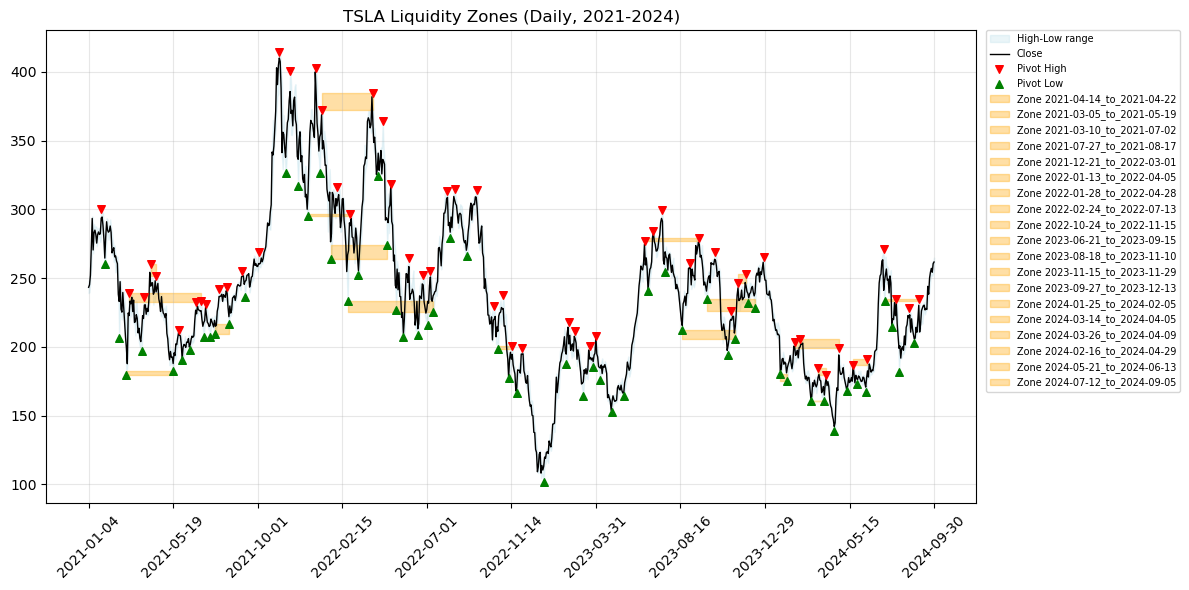

In [259]:
# ---------------------------------------------------------------------------
# Visualize Daily Zones
# ---------------------------------------------------------------------------
plot_zones_matplotlib(
    df_z_daily, zones_df_daily,
    start_date=START_DATE.isoformat(),
    end_date=END_DATE.isoformat(),
    title=f"{TICKER} Liquidity Zones (Daily, {START_DATE.year}-{END_DATE.year})",
    save_dir="charts"
)



## Part 4 — Hourly (LTF) Liquidity Zone Analysis *(Primary)*

This is the **primary** zone detection pass — LTF hourly zones are the direct input for intraday sweep detection (Part 5) and for both model training sets.

Zones are built using a **three-layer filter** to ensure only the highest-conviction price levels are retained:

| Layer | Filter | Controlled by |
|---|---|---|
| **Layer 1** | ATR/pivot structure — local high/low with `pivot_left_right` bars each side | `pivot_left_right`, `atr_merge_mult` |
| **Layer 2** | Volume + absorption — pivot bar must have above-average volume **and** a high absorption score (heavy volume, small body) | `vol_mult`, `MIN_ABSORPTION_SCORE` |
| **Layer 3** | MIDAS institutional confirmation — zone-level average of a dark-pool/order-flow metric must exceed the Nth percentile | `MIDAS_CONFIRM_FIELD`, `MIDAS_CONFIRM_PCT` |

Layer 1+2 produces the **baseline zone set** — the "no order-level data" feature set for the first model.  
Layer 1+2+3 produces the **MIDAS-enriched zone set** — the enriched feature set for the second model.


In [260]:
# ---------------------------------------------------------------------------
# Build Liquidity Zones — Hourly (LTF) [PRIMARY — intraday sweep detection]
# All three layers are applied via identify_liquidity_zones() in one call:
#   Layer 1: ATR/pivot structure (pivot_left_right, atr_merge_mult)
#   Layer 2: volume (vol_mult) + absorption (MIN_ABSORPTION_SCORE)
#   Layer 3: MIDAS enrichment + filter (MIDAS_CONFIRM_FIELD, MIDAS_CONFIRM_PCT)
# Output:
#   zones_df_hourly          — Layer 1+2 baseline  → "no order-level data" model
#   zones_df_hourly_enriched — Layer 1+2+3 enriched → "with order-level data" model
# ---------------------------------------------------------------------------
_hourly = reload_hourly.copy()
_hourly.columns = [c.lower() for c in _hourly.columns]

# Normalize volume column name (required for Layer 2 volume filter)
_VOL_ALIASES = ["tick_volume", "real_volume", "vol", "qty", "quantity"]
if "volume" not in _hourly.columns:
    for alias in _VOL_ALIASES:
        if alias in _hourly.columns:
            _hourly = _hourly.rename(columns={alias: "volume"})
            print(f"[Info] Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column found — volume filtering disabled for hourly data.")

for col in ["open", "high", "low", "close"]:
    if col not in _hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data. Columns: {_hourly.columns.tolist()}")

print(f"Hourly columns: {_hourly.columns.tolist()}")
print("\n=== Processing Hourly Data (LTF — primary) ===")

# Single call: applies all three layers, returns both zone sets and POC values
df_z_hourly, zones_df_hourly, zones_df_hourly_enriched, poc_price_hourly, poc_volume_hourly = identify_liquidity_zones(
    _hourly,
    pivot_left_right=5, atr_len=14, atr_merge_mult=1.0,
    require_volume=("volume" in _hourly.columns), vol_len=20, vol_mult=1.0,
    min_touches=2, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=MIN_ABSORPTION_SCORE,        # Layer 2b: institutional absorption footprint required
    vol_profile_bin=VOL_PROFILE_BIN_HOURLY,
    midas_df=midas_df if USE_MIDAS else None,
    midas_confirm_field=MIDAS_CONFIRM_FIELD,    # Layer 3: MIDAS metric to filter on
    midas_confirm_pct=MIDAS_CONFIRM_PCT,        # Layer 3: percentile threshold
)
print(f"\nLayer 1+2 (ATR/pivot + volume + absorption): {len(zones_df_hourly)} zones")
if poc_price_hourly is not None:
    print(f"POC (hourly, ${VOL_PROFILE_BIN_HOURLY:.2f} bins): ${poc_price_hourly:.2f}  |  bin volume: {poc_volume_hourly:,.0f}")
if USE_MIDAS and midas_df is not None:
    print(f"MIDAS zone enrichment applied: {[c for c in MIDAS_ZONE_COLS if c in zones_df_hourly.columns]}")

# ------------------------------------------------------------------
# Zone count summary: three-layer progression
# ------------------------------------------------------------------
print(f"\n{'─'*68}")
print(f"  LTF Zone Count — Three-Layer Filter Progression")
print(f"{'─'*68}")
print(f"  Layer 1+2   ATR/pivot + volume + absorption (baseline)  : {len(zones_df_hourly):>4} zones")
print(f"  Layer 1+2+3 MIDAS-enriched (≥{MIDAS_CONFIRM_PCT}th pct {MIDAS_CONFIRM_FIELD}) : {len(zones_df_hourly_enriched):>4} zones")
pct_retained = len(zones_df_hourly_enriched) / max(len(zones_df_hourly), 1) * 100
print(f"  MIDAS filter retains {pct_retained:.0f}% of baseline zones")
print(f"{'─'*68}")

# ------------------------------------------------------------------
# Comparison: baseline (no order-level data) vs MIDAS-enriched zones
# ------------------------------------------------------------------
_base_zone_cols_h = [c for c in [
    "zone_id", "top", "bottom", "touches", "strength",
    "avg_absorption", "dist_to_poc", "poc_volume_ratio",
] if c in zones_df_hourly.columns]
_midas_zone_disp_h = [c for c in MIDAS_ZONE_COLS if c in zones_df_hourly.columns]

print("\n— LTF zones: Layer 1+2 baseline (no order-level data) — top 10 by recency —")
display(zones_df_hourly[_base_zone_cols_h].head(10))

if _midas_zone_disp_h:
    _conf_cols = ["zone_id"] + [c for c in _base_zone_cols_h if c != "zone_id"] + _midas_zone_disp_h
    _conf_cols = [c for c in _conf_cols if c in zones_df_hourly_enriched.columns]
    print(f"\n— LTF zones: Layer 1+2+3 MIDAS-enriched ({len(zones_df_hourly_enriched)} zones, ranked by strength) —")
    display(zones_df_hourly_enriched[_conf_cols].head(10))

Hourly columns: ['open', 'high', 'low', 'close', '% change', 'volume', 'vol_roll_20', 'vol_ratio', 'vol_spike', 'absorption_score']

=== Processing Hourly Data (LTF — primary) ===


Layer 3 MIDAS filter (hidden_rate_avg ≥ 50th pct = 27.325): 86/172 zones retained

Layer 1+2 (ATR/pivot + volume + absorption): 172 zones
POC (hourly, $0.50 bins): $229.25  |  bin volume: 577,819,528
MIDAS zone enrichment applied: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']

────────────────────────────────────────────────────────────────────
  LTF Zone Count — Three-Layer Filter Progression
────────────────────────────────────────────────────────────────────
  Layer 1+2   ATR/pivot + volume + absorption (baseline)  :  172 zones
  Layer 1+2+3 MIDAS-enriched (≥50th pct hidden_rate_avg) :   86 zones
  MIDAS filter retains 50% of baseline zones
────────────────────────────────────────────────────────────────────

— LTF zones: Layer 1+2 baseline (no order-level data) — top 10 by recency —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio
0,2021-01-15_to_2021-01-19,286.63,283.01,2,0.026526,7.474472,55.570,1.159103
1,2021-01-25_to_2021-01-26,300.13,298.63,2,0.026739,2.645406,70.130,0.820888
2,2021-01-08_to_2021-02-08,294.83,292.53,2,0.026998,8.669269,64.430,1.229399
3,2021-01-22_to_2021-02-11,276.63,276.23,2,0.025994,3.616361,47.180,1.147001
4,2021-01-15_to_2021-02-16,273.67,273.03,2,0.026314,7.101267,44.100,1.622975
5,2021-01-28_to_2021-02-19,267.00,265.60,3,0.041018,5.436378,37.050,1.963618
6,2021-03-25_to_2021-03-29,203.32,198.67,2,0.028067,2.032680,28.255,2.756055
7,2021-03-17_to_2021-04-01,234.58,230.81,2,0.027907,2.766211,3.445,2.336432
8,2021-04-05_to_2021-04-12,235.85,234.93,2,0.028534,6.924382,6.140,2.708163
9,2021-01-29_to_2021-04-14,261.78,260.03,3,0.043475,4.551262,31.655,2.359565



— LTF zones: Layer 1+2+3 MIDAS-enriched (86 zones, ranked by strength) —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2022-03-11_to_2022-09-26,284.02,280.62,7,0.180602,3.334506,53.070,1.301379,18.205781,38.699050,32.191859,4.511222,90.292839,52.834731
1,2023-10-23_to_2023-11-10,205.69,202.51,3,0.170342,7.360358,25.150,1.087505,28.844687,31.605537,21.627831,2.319995,76.984817,29.420040
2,2021-12-15_to_2022-08-03,312.33,307.99,6,0.143214,4.774269,80.910,0.735556,16.483885,39.329322,33.509686,4.586336,92.132014,56.490420
3,2021-11-26_to_2022-04-21,363.50,356.93,6,0.125576,4.507520,130.965,0.392596,14.417036,39.317402,33.296585,4.413460,92.706566,57.711522
4,2022-08-08_to_2022-08-26,305.17,301.96,5,0.119340,5.475691,74.315,1.223909,22.863765,37.883719,32.084669,4.033090,90.863826,52.187926
5,2021-09-07_to_2021-10-01,254.81,253.40,7,0.118199,4.924247,24.855,2.551281,23.998735,37.940193,27.382566,2.257969,87.475654,47.338873
6,2021-10-19_to_2022-03-03,296.63,292.65,6,0.117456,6.444810,65.390,1.347608,13.767300,38.738917,33.059740,4.139028,91.699680,55.278071
7,2021-10-21_to_2022-04-27,305.99,300.00,5,0.104949,5.271136,73.745,1.336064,13.839200,39.214444,32.967024,4.445473,92.089171,56.423950
8,2023-10-24_to_2023-10-25,222.05,220.10,2,0.104932,1.811449,8.175,2.697579,33.612406,30.712037,23.932170,1.946057,75.874149,29.925177
9,2021-12-22_to_2022-04-12,340.40,337.85,5,0.103437,4.791449,109.875,0.451149,14.251331,39.291262,33.470858,4.609615,92.716813,58.099684



## Part 5 — Liquidity Sweep Detection *(LTF Primary)*

A **liquidity sweep** occurs when price briefly spikes through a prior pivot (triggering stop orders resting beyond it) but then closes back inside — indicating a false breakout that absorbed liquidity.

**Detection logic:**

| Sweep type | Condition |
|---|---|
| Buy-side sweep | `high > last_pivot_high + buffer` **and** `close < last_pivot_high` |
| Sell-side sweep | `low < last_pivot_low − buffer` **and** `close > last_pivot_low` |

where `buffer = 0.10 × ATR(14)` to avoid noise.

**Two sweep tables are produced for LTF (primary intraday analysis):**

| Table | Zone set used for tagging | Model use |
|---|---|---|
| `sweeps_tagged_hourly` | All LTF zones (Layer 1+2: volume + absorption) | Baseline — "no order-level data" model |
| `sweeps_tagged_hourly_enriched` | MIDAS-enriched LTF zones (Layer 1+2+3) | enriched — "with order-level data" model |

HTF (daily) sweeps are also computed and displayed as **supplementary structural context** — they are not the primary analysis target.

**Sweep-bar feature columns:**

| Column | Description |
|---|---|
| `sweep_vol` | Raw volume of the sweep bar |
| `sweep_vol_ratio` | Relative volume; high values indicate institutional involvement |
| `sweep_vol_spike` | `True` if the sweep coincided with a volume spike |
| `dist_to_nearest_avwap` | Min distance from sweep close to any VWAP anchored from the top-5 zones; small = sweep at institutional fair-value reference |
| `sweep_near_zone` | `True` if sweep occurred near a zone in the tagged zone set |
| MIDAS sweep columns | Day-of-sweep institutional order-flow metrics (when `USE_MIDAS = True`) |

> The key comparison is: **how many more (or fewer) high-conviction sweeps are identified when using MIDAS-enriched zones** versus all volume-filtered zones — this quantifies the marginal benefit of order-level data.


In [261]:

# ---------------------------------------------------------------------------
# Detect & Tag Liquidity Sweeps — LTF (PRIMARY) and HTF (supplementary context)
# ---------------------------------------------------------------------------
# LTF produces two sweep tables for direct model comparison:
#   sweeps_tagged_hourly          — tagged near Layer 1+2 zones  → "no order-level data" baseline
#   sweeps_tagged_hourly_enriched — tagged near Layer 1+2+3 zones → "with order-level data" enriched
#
# HTF produces one sweep table used only as structural context.
# ---------------------------------------------------------------------------
sweep_cols = [
    "buy_side_sweep", "sell_side_sweep", "swept_level",
    "sweep_vol", "sweep_vol_ratio", "sweep_vol_spike",
    "sweep_near_zone", "sweep_zone_id",
    "dist_to_nearest_avwap",
]

# ── [Supplementary] HTF daily sweeps — structural context only ─────────────
sweeps_df_daily = detect_liquidity_sweeps(
    _daily, left=3, right=3, atr_len=14, buffer_atr=0.10, unique_pivots=True,
    use_vol_filter=USE_VOL_FILTER, vol_spike_threshold=VOL_SPIKE_THRESHOLD,
)
sweeps_tagged_daily = tag_sweeps_at_zones(
    sweeps_df_daily, zones_df_daily, proximity_atr_mult=0.25, max_days_after_zone_end=0
)

# ── [PRIMARY] LTF hourly sweeps — intraday sweep detection ─────────────────
sweeps_df_hourly = detect_liquidity_sweeps(
    _hourly, left=3, right=3, atr_len=14, buffer_atr=0.10, unique_pivots=True,
    use_vol_filter=USE_VOL_FILTER, vol_spike_threshold=VOL_SPIKE_THRESHOLD,
)

# Baseline: tag near all Layer 1+2 LTF zones (no order-level data)
sweeps_tagged_hourly = tag_sweeps_at_zones(
    sweeps_df_hourly, zones_df_hourly,
    proximity_atr_mult=0.25, max_days_after_zone_end=0
)

# enriched: tag near Layer 1+2+3 MIDAS-enriched LTF zones only (with order-level data)
sweeps_tagged_hourly_enriched = tag_sweeps_at_zones(
    sweeps_df_hourly, zones_df_hourly_enriched,
    proximity_atr_mult=0.25, max_days_after_zone_end=0
)

# Anchored VWAP — anchor from top-5 zones by strength; attach distance to each sweep bar
avwap_df_daily  = compute_anchored_vwaps(_daily,  zones_df_daily,  n_top=5)
avwap_df_hourly = compute_anchored_vwaps(_hourly, zones_df_hourly, n_top=5)

sweeps_tagged_daily             = add_sweep_avwap_dist(sweeps_tagged_daily,             avwap_df_daily)
sweeps_tagged_hourly            = add_sweep_avwap_dist(sweeps_tagged_hourly,            avwap_df_hourly)
sweeps_tagged_hourly_enriched   = add_sweep_avwap_dist(sweeps_tagged_hourly_enriched,   avwap_df_hourly)

# MIDAS enrichment — attach day-of-sweep institutional microstructure metrics to all bars
if USE_MIDAS and midas_df is not None:
    sweeps_tagged_daily             = enrich_sweeps_midas(sweeps_tagged_daily,             midas_df)
    sweeps_tagged_hourly            = enrich_sweeps_midas(sweeps_tagged_hourly,            midas_df)
    sweeps_tagged_hourly_enriched   = enrich_sweeps_midas(sweeps_tagged_hourly_enriched,   midas_df)
    print(f"MIDAS sweep enrichment applied: {[c for c in MIDAS_SWEEP_COLS if c in sweeps_tagged_hourly.columns]}")

# ------------------------------------------------------------------
# Sweep count summary — layered zone filter comparison
# ------------------------------------------------------------------
_sweep_mask_h = (
    sweeps_tagged_hourly["buy_side_sweep"].fillna(False) |
    sweeps_tagged_hourly["sell_side_sweep"].fillna(False)
)
n_hourly_total    = int(_sweep_mask_h.sum())
n_near_all_zones  = int(sweeps_tagged_hourly["sweep_near_zone"].fillna(False).sum())
n_near_enh_zones  = int(sweeps_tagged_hourly_enriched["sweep_near_zone"].fillna(False).sum())
pct_of_baseline   = n_near_enh_zones / max(n_near_all_zones, 1) * 100

print(f"\n{'─'*70}")
print(f"  LTF (Hourly) Sweep Count — Zone Filter Comparison")
print(f"{'─'*70}")
print(f"  Total hourly sweeps detected                             : {n_hourly_total:>5}")
print(f"  Near any Layer 1+2 zone       [baseline — no MIDAS]     : {n_near_all_zones:>5}")
print(f"  Near Layer 1+2+3 MIDAS zone   [enriched — with MIDAS]   : {n_near_enh_zones:>5}  ({pct_of_baseline:.0f}% of baseline)")
print(f"{'─'*70}")

# ------------------------------------------------------------------
# Display — PRIMARY: LTF (hourly) sweeps
# ------------------------------------------------------------------
avail_sweep_cols_h  = [c for c in sweep_cols if c in sweeps_tagged_hourly.columns]
_midas_sweep_disp_h = [c for c in MIDAS_SWEEP_COLS if c in sweeps_tagged_hourly.columns]

print("\n=== LTF Sweeps — Baseline: near any zone, no order-level data (last 10) ===")
display(sweeps_tagged_hourly[avail_sweep_cols_h].tail(10))

if _midas_sweep_disp_h:
    _enh_near = sweeps_tagged_hourly_enriched[
        sweeps_tagged_hourly_enriched["sweep_near_zone"].fillna(False)
    ]
    print(f"\n=== LTF Sweeps — enriched: near MIDAS-enriched zones ({len(_enh_near)} qualifying sweeps, last 10) ===")
    _enh_disp_cols = [c for c in avail_sweep_cols_h + _midas_sweep_disp_h if c in _enh_near.columns]
    display(_enh_near[_enh_disp_cols].tail(10) if not _enh_near.empty
            else pd.DataFrame(columns=_enh_disp_cols))

# ------------------------------------------------------------------
# Display — SUPPLEMENTARY: HTF (daily) sweeps for context
# ------------------------------------------------------------------
avail_sweep_cols_d  = [c for c in sweep_cols if c in sweeps_tagged_daily.columns]
_midas_sweep_disp_d = [c for c in MIDAS_SWEEP_COLS if c in sweeps_tagged_daily.columns]

print("\n=== HTF (Daily) Sweeps — Supplementary context (last 10) ===")
display(sweeps_tagged_daily[avail_sweep_cols_d].tail(10))
if _midas_sweep_disp_d:
    print("\n=== HTF (Daily) Sweeps — MIDAS additions (last 10) ===")
    display(sweeps_tagged_daily[_midas_sweep_disp_d].tail(10))


MIDAS sweep enrichment applied: ['sweep_cancel_to_trade', 'sweep_hidden_rate', 'sweep_hidden_volume', 'sweep_fill_rate', 'sweep_oddlot_rate', 'sweep_oddlot_volume']

──────────────────────────────────────────────────────────────────────
  LTF (Hourly) Sweep Count — Zone Filter Comparison
──────────────────────────────────────────────────────────────────────
  Total hourly sweeps detected                             :   164
  Near any Layer 1+2 zone       [baseline — no MIDAS]     :   137
  Near Layer 1+2+3 MIDAS zone   [enriched — with MIDAS]   :    60  (44% of baseline)
──────────────────────────────────────────────────────────────────────

=== LTF Sweeps — Baseline: near any zone, no order-level data (last 10) ===


,buy_side_sweep,sell_side_sweep,swept_level,sweep_vol,sweep_vol_ratio,sweep_vol_spike,sweep_near_zone,sweep_zone_id,dist_to_nearest_avwap
Datetime,,,,,,,,,
2024-09-27 13:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-27 14:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-27 15:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-30 09:30:00,True,False,261.75,25611610.0,2.776501,True,False,NaN,27.821378
2024-09-30 10:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-30 11:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-30 12:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-30 13:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-30 14:30:00,False,False,NaN,NaN,NaN,False,False,NaN,NaN



=== LTF Sweeps — enriched: near MIDAS-enriched zones (60 qualifying sweeps, last 10) ===


,buy_side_sweep,sell_side_sweep,swept_level,sweep_vol,sweep_vol_ratio,sweep_vol_spike,sweep_near_zone,sweep_zone_id,dist_to_nearest_avwap,sweep_cancel_to_trade,sweep_hidden_rate,sweep_hidden_volume,sweep_fill_rate,sweep_oddlot_rate,sweep_oddlot_volume
Datetime,,,,,,,,,,,,,,,
2022-08-12 09:30:00,False,True,288.13,19763895.0,1.751475,True,True,2022-08-05_to_2022-08-30,NaN,23.498229,34.452546,29.534868,3.550156,91.030312,50.878866
2022-08-16 09:30:00,True,False,313.08,30042090.0,2.699448,True,True,2022-08-08_to_2022-08-26,NaN,22.157942,39.056432,31.964968,4.450974,91.855347,53.035470
2022-09-01 09:30:00,False,True,271.84,13610444.0,2.164364,True,True,2022-08-31_to_2022-09-26,NaN,19.665601,34.701537,26.848782,3.743222,84.605309,40.237074
2022-09-15 09:30:00,True,False,306.00,20129871.0,2.319492,True,True,2022-09-12_to_2022-09-15,NaN,15.293263,35.428145,27.430101,4.032036,79.792143,36.342279
2022-09-21 14:30:00,True,True,310.48,14958525.0,1.776700,True,True,2022-08-04_to_2022-09-21,NaN,19.490830,37.381594,31.111678,3.009264,79.561777,36.352183
2022-10-14 09:30:00,True,False,219.20,25940115.0,2.372403,True,True,2022-10-10_to_2022-10-28,NaN,15.484639,29.967921,27.060741,3.512765,78.538861,33.843286
2022-10-18 09:30:00,True,False,221.83,21577991.0,1.877320,True,True,2022-10-14_to_2022-10-18,NaN,13.862740,32.385088,27.663465,4.551218,75.683987,32.060524
2022-10-27 09:30:00,True,False,230.49,23789825.0,1.940346,True,True,2022-10-26_to_2022-10-27,NaN,16.044145,35.543053,28.825825,3.414357,74.623801,32.169307
2022-12-23 09:30:00,False,True,122.26,56771140.0,2.342190,True,True,2022-12-23_to_2022-12-29,NaN,9.920622,27.745842,21.232678,5.880336,70.045885,23.681987



=== HTF (Daily) Sweeps — Supplementary context (last 10) ===


,buy_side_sweep,sell_side_sweep,swept_level,sweep_vol,sweep_vol_ratio,sweep_vol_spike,sweep_near_zone,sweep_zone_id,dist_to_nearest_avwap
Datetime,,,,,,,,,
2024-09-17,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-18,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-19,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-20,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-23,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-24,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-25,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-26,False,False,NaN,NaN,NaN,False,False,NaN,NaN
2024-09-27,False,False,NaN,NaN,NaN,False,False,NaN,NaN



=== HTF (Daily) Sweeps — MIDAS additions (last 10) ===


,sweep_cancel_to_trade,sweep_hidden_rate,sweep_hidden_volume,sweep_fill_rate,sweep_oddlot_rate,sweep_oddlot_volume
Datetime,,,,,,
2024-09-17,30.188152,21.397974,19.376242,2.145458,77.549921,29.768970
2024-09-18,32.069880,22.411338,19.922394,2.019752,78.349891,30.121854
2024-09-19,24.546650,19.735688,20.301459,2.701773,75.108458,27.011655
2024-09-20,32.669296,19.982056,26.437227,1.972661,77.146487,27.766852
2024-09-23,21.344509,20.007210,20.956380,2.965355,77.864844,27.977851
2024-09-24,35.657190,21.208129,21.719910,1.840788,78.386400,29.325258
2024-09-25,32.136996,19.291262,18.047930,2.047854,79.685393,30.009501
2024-09-26,28.694872,22.569841,22.741522,2.082493,80.232638,30.956435
2024-09-27,26.615372,22.317862,18.830946,2.590407,77.421812,28.826407


/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_34216/1120650361.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Chart saved to charts/TSLA_Liquidity_Zones_(Hourly,_2021-2024).png


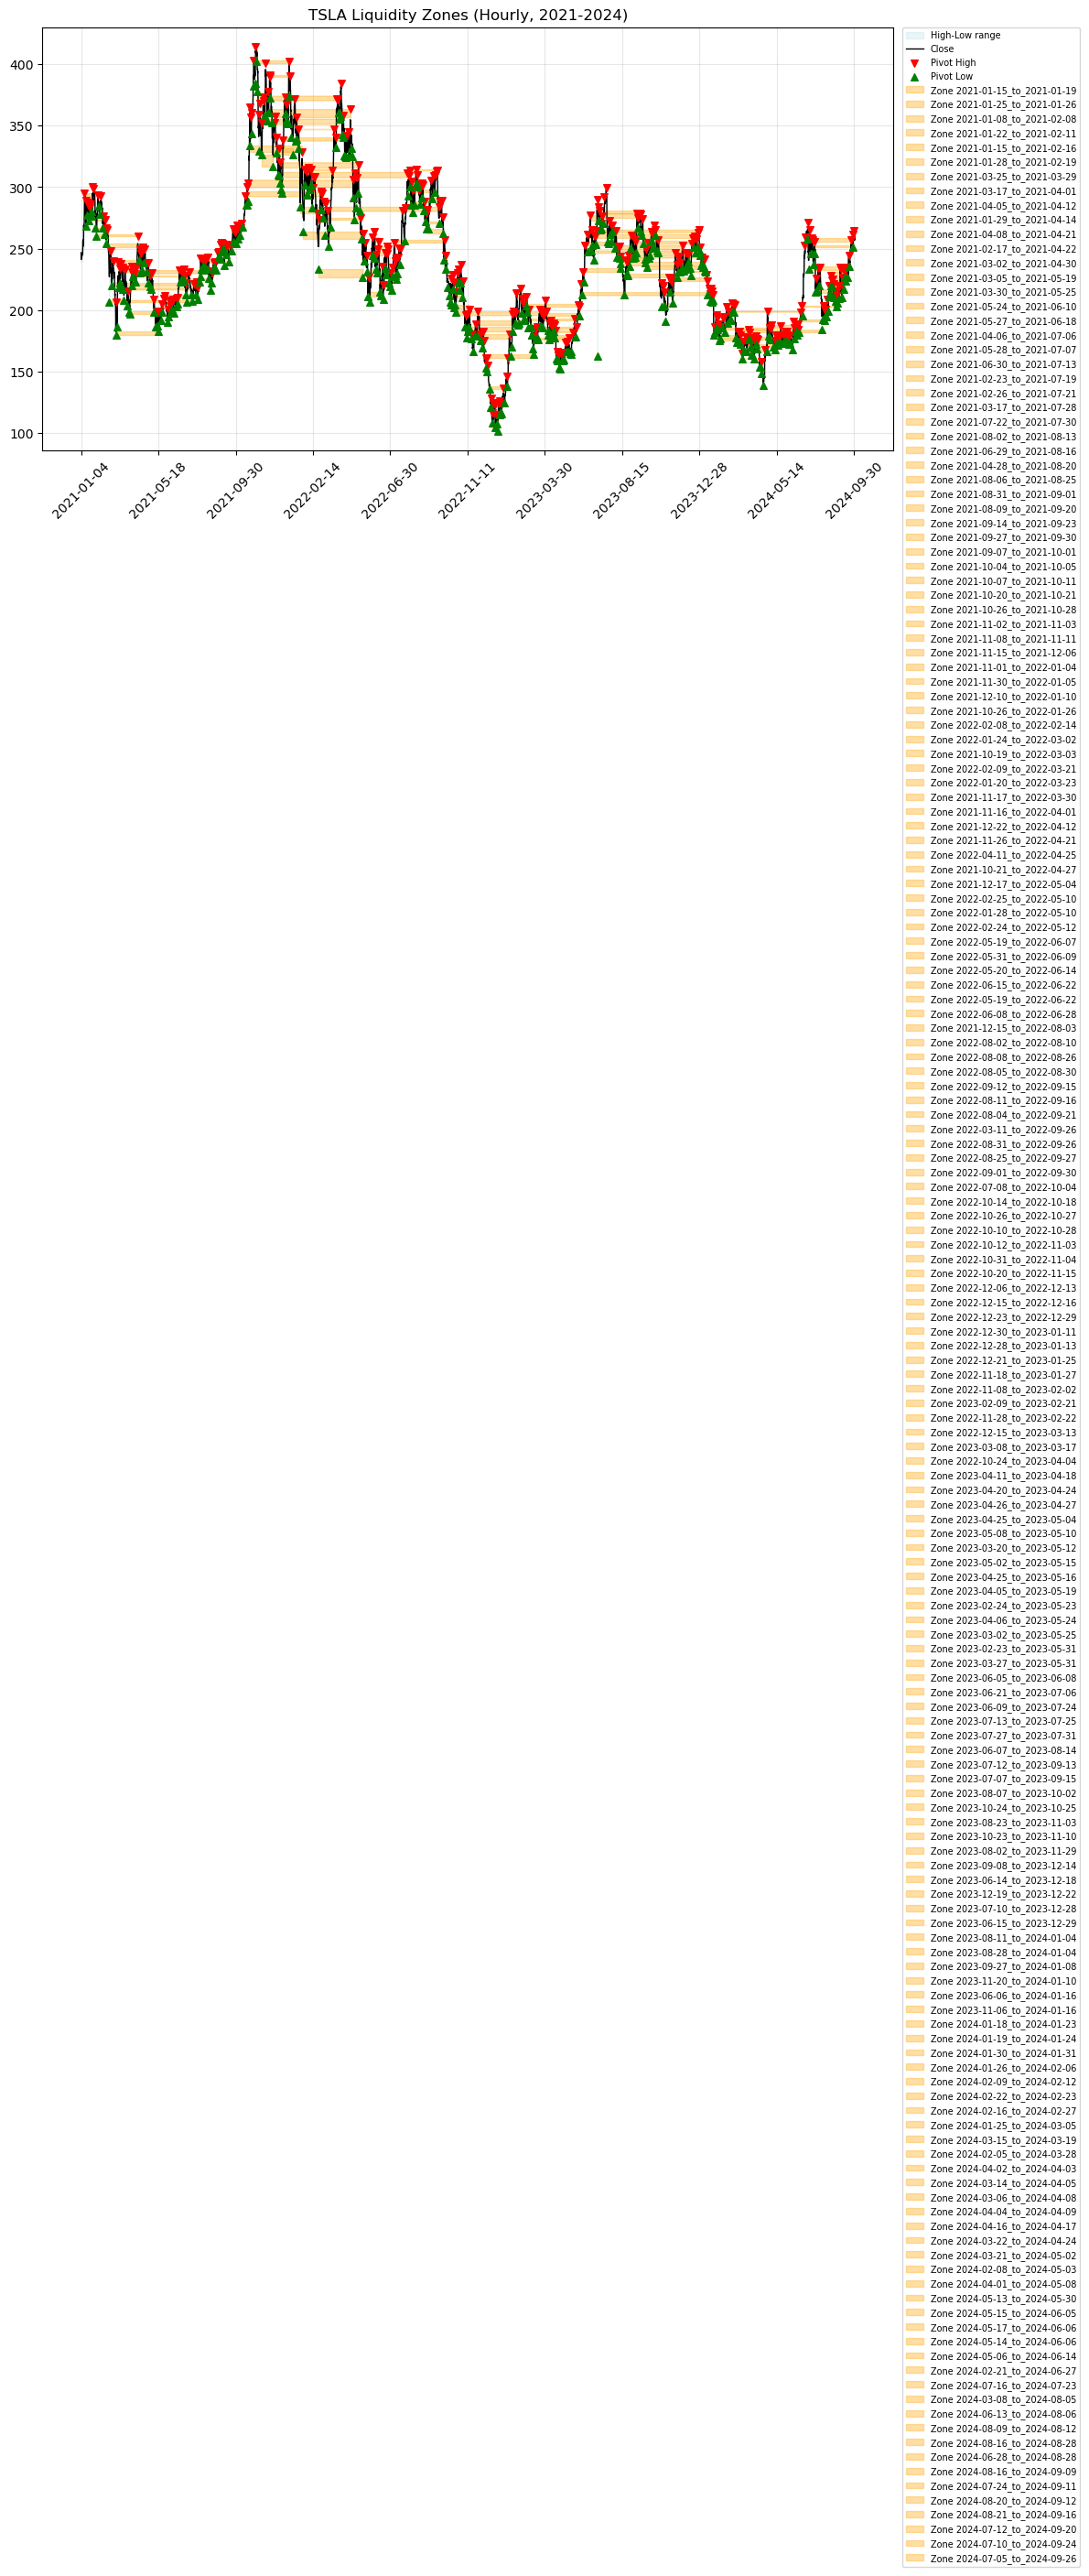

In [262]:
# ---------------------------------------------------------------------------
# Visualize Hourly Zones
# ---------------------------------------------------------------------------
plot_zones_matplotlib(
    df_z_hourly, zones_df_hourly,
    start_date=START_DATE.isoformat(),
    end_date=END_DATE.isoformat(),
    title=f"{TICKER} Liquidity Zones (Hourly, {START_DATE.year}-{END_DATE.year})",
    save_dir="charts"
)



## Part 6 — Export Results to Excel

Save all outputs for both timeframes to separate Excel workbooks.

| File | Contents |
|---|---|
| `TSLA_results_daily.xlsx` | HTF daily results (structural context) |
| `TSLA_results_hourly.xlsx` | LTF hourly results — **primary analysis** |

### Hourly workbook sheet layout (primary):

| Sheet | Contents | Model use |
|---|---|---|
| `OHLCV` | Price bars + sweep flags + bar-level volume features | Both models |
| `Liquidity_Zones` | All Layer 1+2 zones with volume features + MIDAS averages | Both models |
| `Sweeps` | Full sweep-detection output for all hourly bars | Both models |
| `Tagged_Sweeps` | Sweeps tagged near **any** LTF zone; includes MIDAS sweep columns | **"No order-level data"** baseline model |
| `Tagged_Sweeps_enriched` | Sweeps tagged near **MIDAS-enriched** LTF zones only | **"With order-level data"** enriched model |
| `MIDAS_Zones` | Zone-level MIDAS averages in isolation | "With order-level data" model |
| `MIDAS_Sweeps` | Sweep-bar MIDAS values in isolation | "With order-level data" model |
| `MIDAS_enriched_Zones` | Layer 1+2+3 zone subset (MIDAS-enriched), with all features | "With order-level data" model |

> `Tagged_Sweeps` vs `Tagged_Sweeps_enriched` is the key pair for dual-model comparison: same sweeps, different zone tagging — shows exactly what MIDAS enrichment adds.


In [263]:

# ---------------------------------------------------------------------------
# Save Results to Excel — Daily (context) & Hourly (primary)
# ---------------------------------------------------------------------------
ohlcv_base_cols = [
    "open", "high", "low", "close", "volume",
    "vol_roll_20", "vol_ratio", "vol_spike", "absorption_score",
]

# Sweep columns for each tagged table
_sweep_tag_base = [
    "buy_side_sweep", "sell_side_sweep", "swept_level",
    "sweep_vol", "sweep_vol_ratio", "sweep_vol_spike",
    "sweep_near_zone", "sweep_zone_id",
    "dist_to_nearest_avwap",
]

for label, df_z, zones_df, sweeps_df, sweeps_tagged, zones_enriched, sweeps_enriched in [
    # daily: no enriched set (HTF context only)
    ("daily",  df_z_daily,  zones_df_daily,  sweeps_df_daily,  sweeps_tagged_daily,  None, None),
    # hourly: both baseline and enriched sets
    ("hourly", df_z_hourly, zones_df_hourly, sweeps_df_hourly, sweeps_tagged_hourly,
     zones_df_hourly_enriched, sweeps_tagged_hourly_enriched),
]:
    avail_ohlcv  = [c for c in ohlcv_base_cols if c in df_z.columns]
    tag_cols_all = (
        _sweep_tag_base +
        [c for c in MIDAS_SWEEP_COLS if c in sweeps_tagged.columns] +
        avail_ohlcv
    )

    excel_path = f"{TICKER}_results_{label}.xlsx"
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

        # ── Core sheets (shared by both models) ────────────────────────────
        sweep_cols_basic = sweeps_df[["buy_side_sweep", "sell_side_sweep", "swept_level"]]
        ohlcv_zone = df_z[avail_ohlcv].join(sweep_cols_basic).assign(zone_id=df_z["zone_id"])
        ohlcv_zone.to_excel(writer, index=True,  sheet_name="OHLCV")
        zones_df.to_excel(writer,   index=False, sheet_name="Liquidity_Zones")
        sweeps_df.to_excel(writer,  index=True,  sheet_name="Sweeps")

        # ── "No order-level data" baseline sweep table ─────────────────────
        avail_tag_cols = [c for c in tag_cols_all if c in sweeps_tagged.columns]
        sweeps_tagged[avail_tag_cols].to_excel(writer, index=True, sheet_name="Tagged_Sweeps")

        # ── "With order-level data" enriched sheets ─────────────────────────
        if USE_MIDAS and midas_df is not None:
            # MIDAS zone and sweep views for both timeframes
            avail_midas_zone_cols  = [c for c in MIDAS_ZONE_COLS  if c in zones_df.columns]
            avail_midas_sweep_cols = [c for c in MIDAS_SWEEP_COLS if c in sweeps_tagged.columns]
            if avail_midas_zone_cols:
                zones_df[["zone_id"] + avail_midas_zone_cols].to_excel(
                    writer, index=False, sheet_name="MIDAS_Zones"
                )
            if avail_midas_sweep_cols:
                sweeps_tagged[avail_midas_sweep_cols].to_excel(
                    writer, index=True, sheet_name="MIDAS_Sweeps"
                )

            # Hourly-only: MIDAS-enriched zone set and enriched sweep table
            if zones_enriched is not None and sweeps_enriched is not None:
                # MIDAS-enriched zone set — Layer 1+2+3
                _base_zcols = ["zone_id", "top", "bottom", "touches", "strength",
                               "avg_absorption", "dist_to_poc", "poc_volume_ratio"]
                _enh_zone_cols = [c for c in _base_zcols + avail_midas_zone_cols
                                  if c in zones_enriched.columns]
                zones_enriched[_enh_zone_cols].to_excel(
                    writer, index=False, sheet_name="MIDAS_enriched_Zones"
                )
                # Sweeps tagged near MIDAS-enriched zones (the "with order-level data" sweep set)
                avail_enh_sweep_cols = [c for c in tag_cols_all if c in sweeps_enriched.columns]
                sweeps_enriched[avail_enh_sweep_cols].to_excel(
                    writer, index=True, sheet_name="Tagged_Sweeps_enriched"
                )

    print(f"Saved {label} results -> {excel_path}")


Saved daily results -> TSLA_results_daily.xlsx
Saved hourly results -> TSLA_results_hourly.xlsx
